In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")
sample_submission = pd.read_csv("../data/raw/sample_submission.csv")

In [3]:
train.head()

,customer_age,product_price,discount_percent,product_rating,past_purchase_count,past_return_rate,delivery_delay_days,session_length_minutes,num_product_views,device_type,product_category,shipping_method,payment_method,used_coupon,returned,order_id
0,25,11.666137,43.559601,1.933533,8,0.331408,-0.089637,3.273029,26,tablet,sports,express,paypal,1,0,75381
1,76,31.378967,66.526039,0.690237,9,0.105203,3.639277,130.513123,8,mobile,electronics,standard,credit_card,1,0,65569
2,40,25.460603,20.762374,2.347620,14,0.236683,0.294060,92.780917,-2,desktop,toys,express,credit_card,0,0,163473
3,62,13.517170,25.669260,2.033596,9,0.410038,1.683333,103.004177,7,mobile,clothing,express,apple_pay,0,0,90518
4,51,75.771311,15.527927,4.907556,9,0.123565,-0.153691,100.752658,6,mobile,electronics,standard,credit_card,1,0,138866


In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (200000, 16)
Test shape: (50000, 15)
Sample submission shape: (50000, 2)


Train содержит 200 000 строк и 16 колонок. Test содержит 50 000 строк и 15 колонок.
В train есть таргет `returned`, в test таргета нет. Поэтому для оценки качества
используется внутренний train/validation/internal test split из train.csv.

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   customer_age            200000 non-null  int64  
 1   product_price           200000 non-null  float64
 2   discount_percent        200000 non-null  float64
 3   product_rating          200000 non-null  float64
 4   past_purchase_count     200000 non-null  int64  
 5   past_return_rate        200000 non-null  float64
 6   delivery_delay_days     200000 non-null  float64
 7   session_length_minutes  200000 non-null  float64
 8   num_product_views       200000 non-null  int64  
 9   device_type             200000 non-null  str    
 10  product_category        200000 non-null  str    
 11  shipping_method         200000 non-null  str    
 12  payment_method          200000 non-null  str    
 13  used_coupon             200000 non-null  int64  
 14  returned                200000 

In [6]:
train.isna().sum().sort_values(ascending=False)

customer_age              0
product_price             0
discount_percent          0
product_rating            0
past_purchase_count       0
past_return_rate          0
delivery_delay_days       0
session_length_minutes    0
num_product_views         0
device_type               0
product_category          0
shipping_method           0
payment_method            0
used_coupon               0
returned                  0
order_id                  0
dtype: int64

Пропущенных значений в данных не обнаружено.

In [7]:
train.duplicated().sum()

np.int64(0)

Полных дубликатов в данных не обнаружено.

In [8]:
train["returned"].value_counts()

returned
0    105081
1     94919
Name: count, dtype: int64

In [9]:
train["returned"].value_counts(normalize=True)

returned
0    0.525405
1    0.474595
Name: proportion, dtype: float64

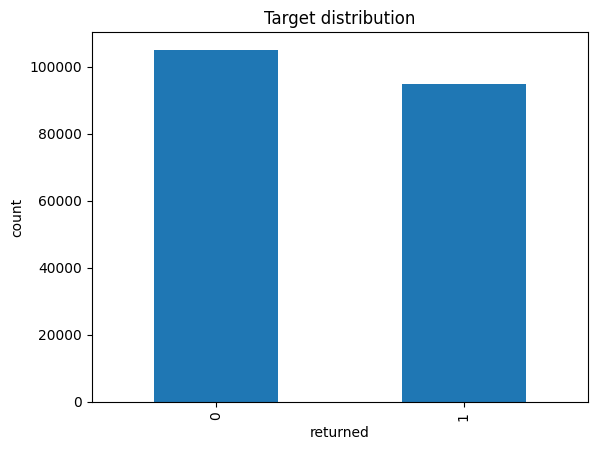

In [10]:
train["returned"].value_counts().sort_index().plot(kind="bar")
plt.title("Target distribution")
plt.xlabel("returned")
plt.ylabel("count")
plt.show()

Классы почти сбалансированы: доля возвратов около 47.5%.

In [11]:
categorical_cols = [
    "device_type",
    "product_category",
    "shipping_method",
    "payment_method",
]

for col in categorical_cols:
    print(col)
    display(train[col].value_counts())

device_type


device_type
mobile     109371
desktop     48903
tablet      41726
Name: count, dtype: int64

product_category


product_category
toys           48287
beauty         37100
electronics    36092
home           31839
clothing       23913
sports         22769
Name: count, dtype: int64

shipping_method


shipping_method
standard    131311
express      53088
same_day     15601
Name: count, dtype: int64

payment_method


payment_method
debit_card     56667
credit_card    54743
apple_pay      47518
paypal         41072
Name: count, dtype: int64

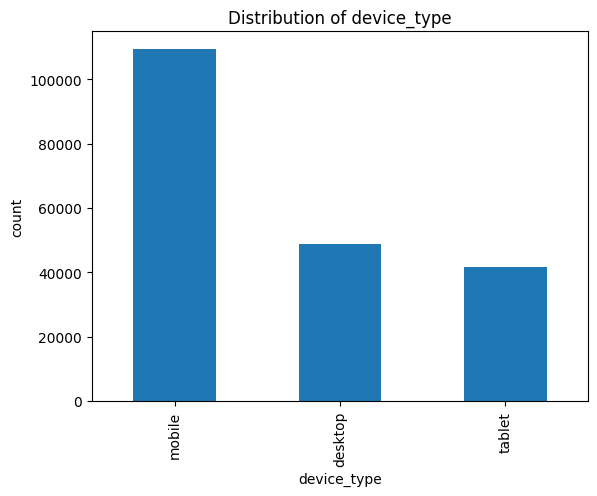

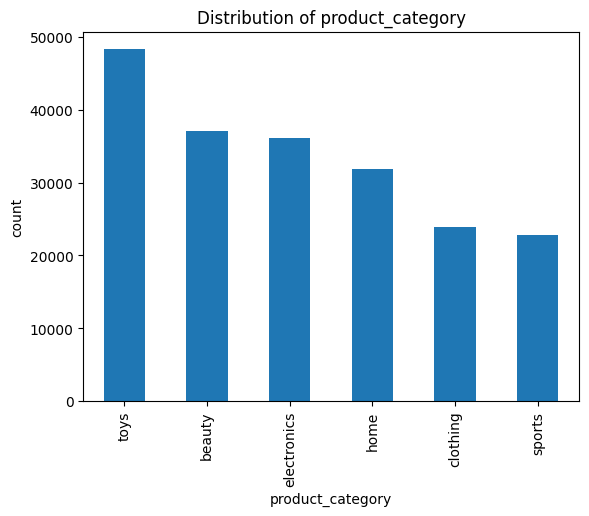

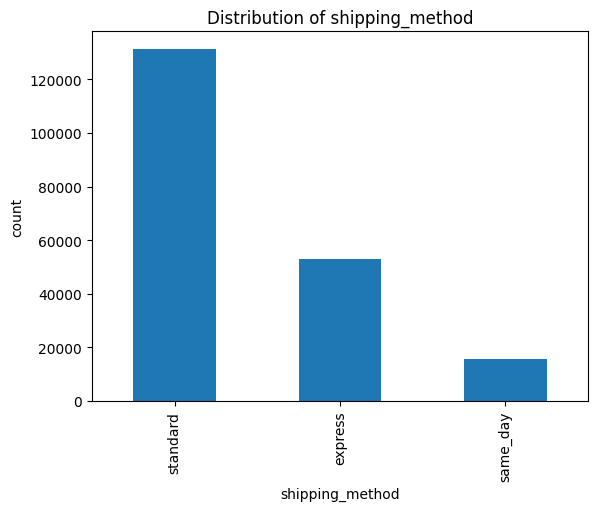

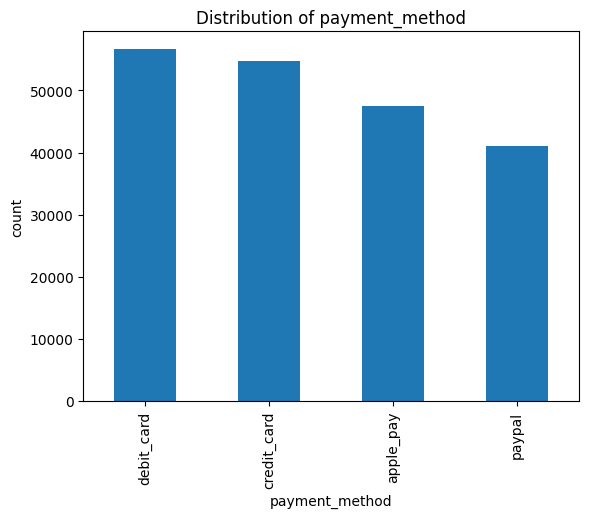

In [12]:
for col in categorical_cols:
    train[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

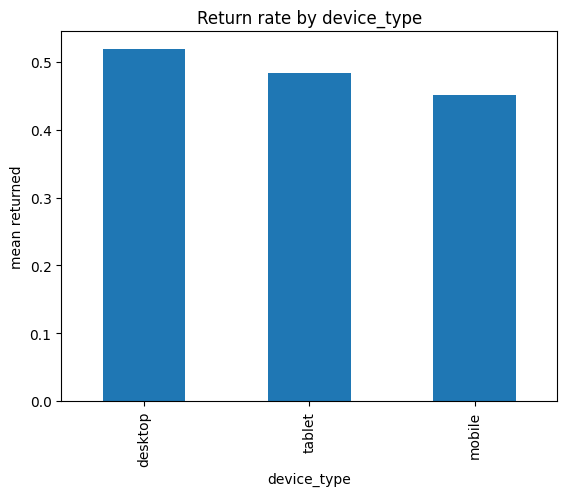

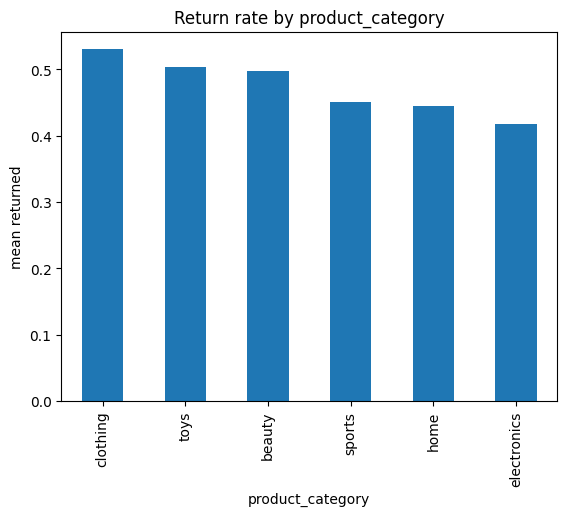

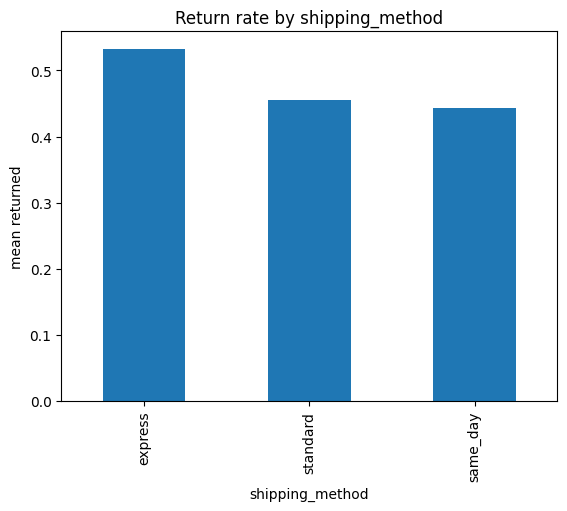

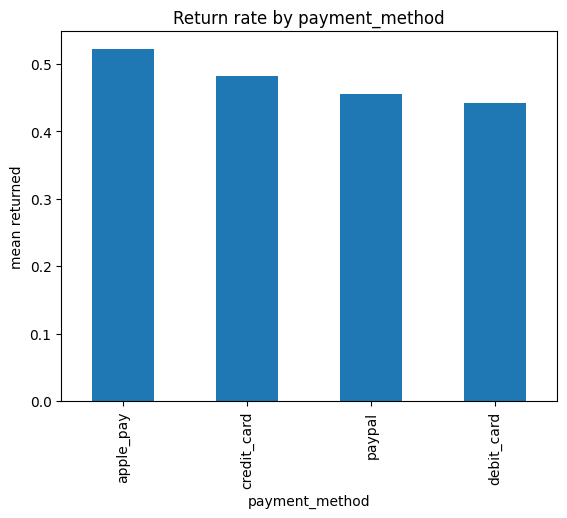

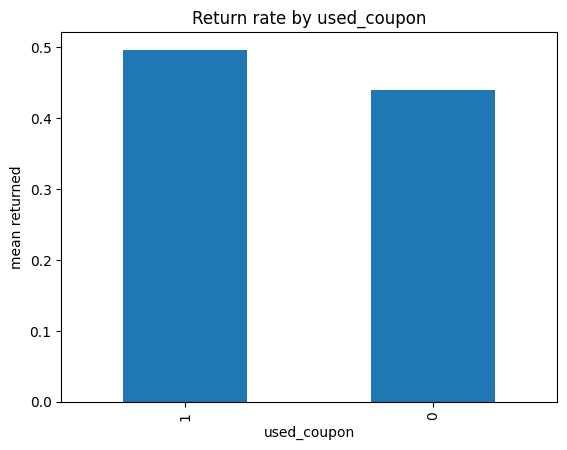

In [13]:
for col in categorical_cols + ["used_coupon"]:
    (
        train.groupby(col)["returned"]
        .mean()
        .sort_values(ascending=False)
        .plot(kind="bar")
    )
    plt.title(f"Return rate by {col}")
    plt.ylabel("mean returned")
    plt.show()

Категориальные признаки имеют разные средние значения таргета.
Значит, категория товара, тип устройства, способ доставки и способ оплаты
могут быть полезны для предсказания возврата.

In [14]:
invalid_stats = {
    "product_price < 0": (train["product_price"] < 0).sum(),
    "discount_percent < 0": (train["discount_percent"] < 0).sum(),
    "discount_percent > 100": (train["discount_percent"] > 100).sum(),
    "product_rating < 1": (train["product_rating"] < 1).sum(),
    "product_rating > 5": (train["product_rating"] > 5).sum(),
    "past_return_rate < 0": (train["past_return_rate"] < 0).sum(),
    "past_return_rate > 1": (train["past_return_rate"] > 1).sum(),
    "session_length_minutes < 0": (train["session_length_minutes"] < 0).sum(),
    "num_product_views < 0": (train["num_product_views"] < 0).sum(),
}

pd.Series(invalid_stats).sort_values(ascending=False)

product_price < 0             27285
num_product_views < 0         21443
product_rating < 1            14280
product_rating > 5             3831
past_return_rate < 0           2220
discount_percent < 0           1686
session_length_minutes < 0     1487
discount_percent > 100            0
past_return_rate > 1              0
dtype: int64

 невозможные значения: отрицательная цена, отрицательная скидка,
рейтинг вне диапазона [1, 5], отрицательная длина сессии и отрицательное количество
просмотров товара.

В preprocessing pipeline такие значения обрезаются до допустимых диапазонов,
а также создаются флаги `invalid_*`.

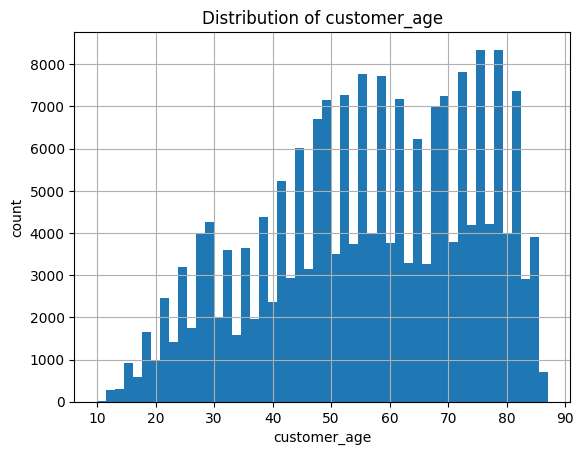

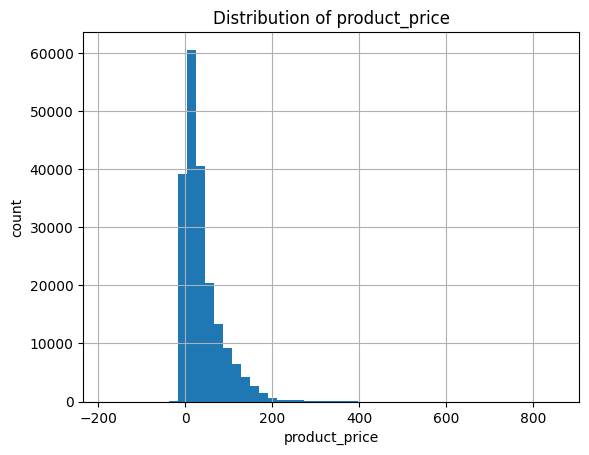

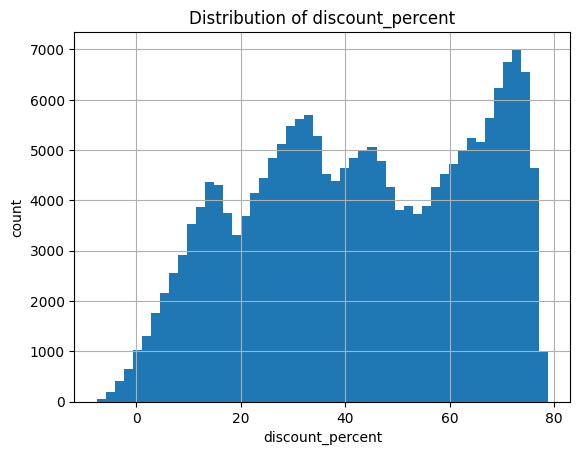

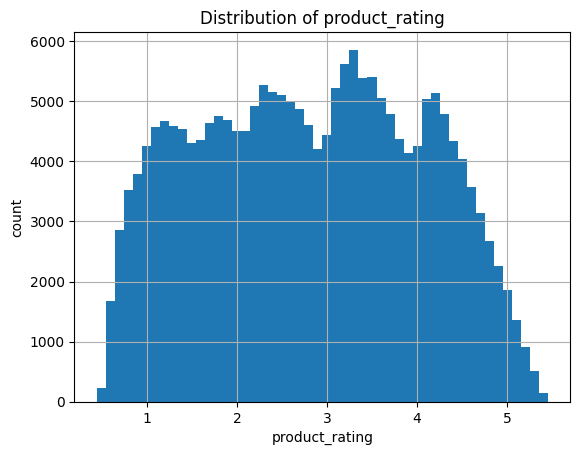

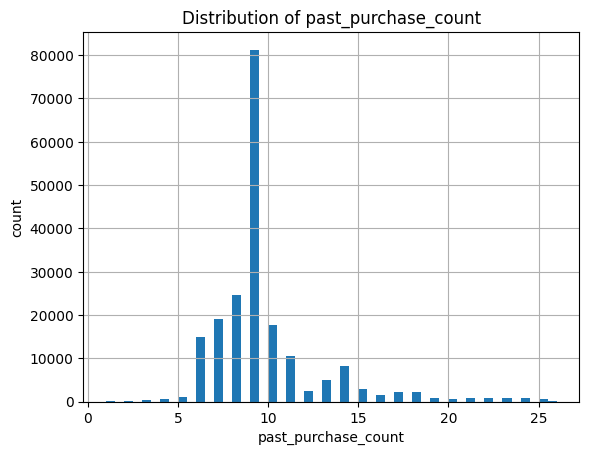

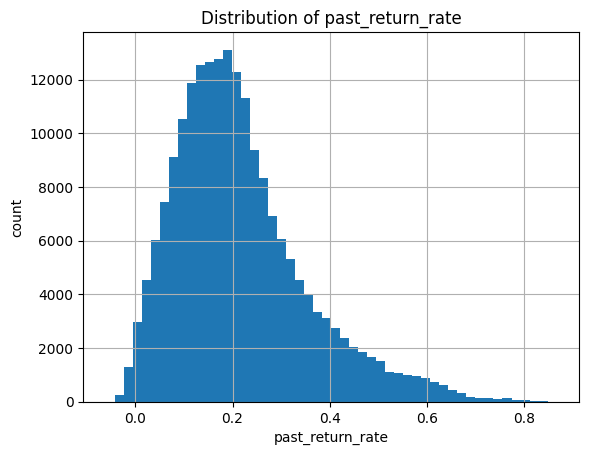

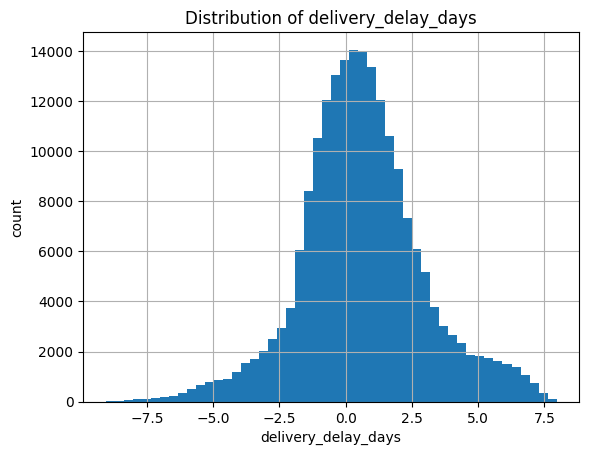

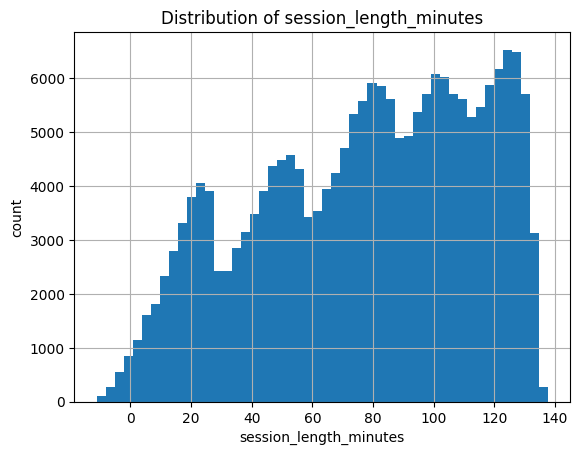

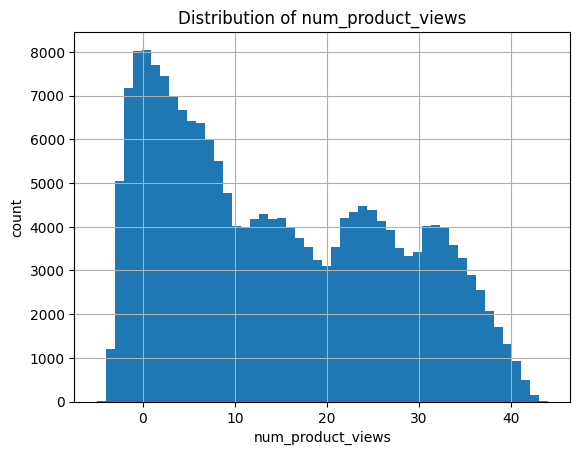

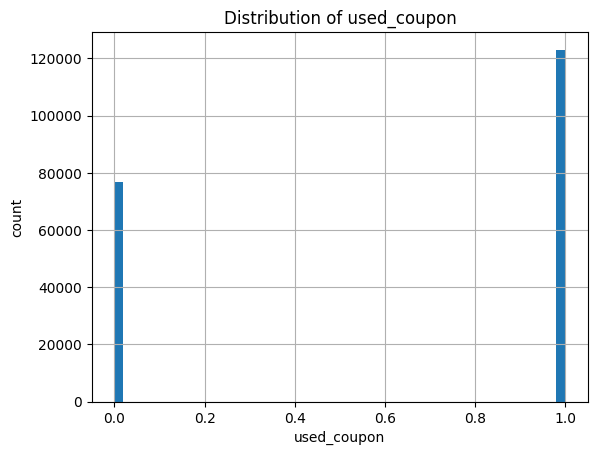

In [15]:
numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ["returned", "order_id"]]

for col in numeric_cols:
    train[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

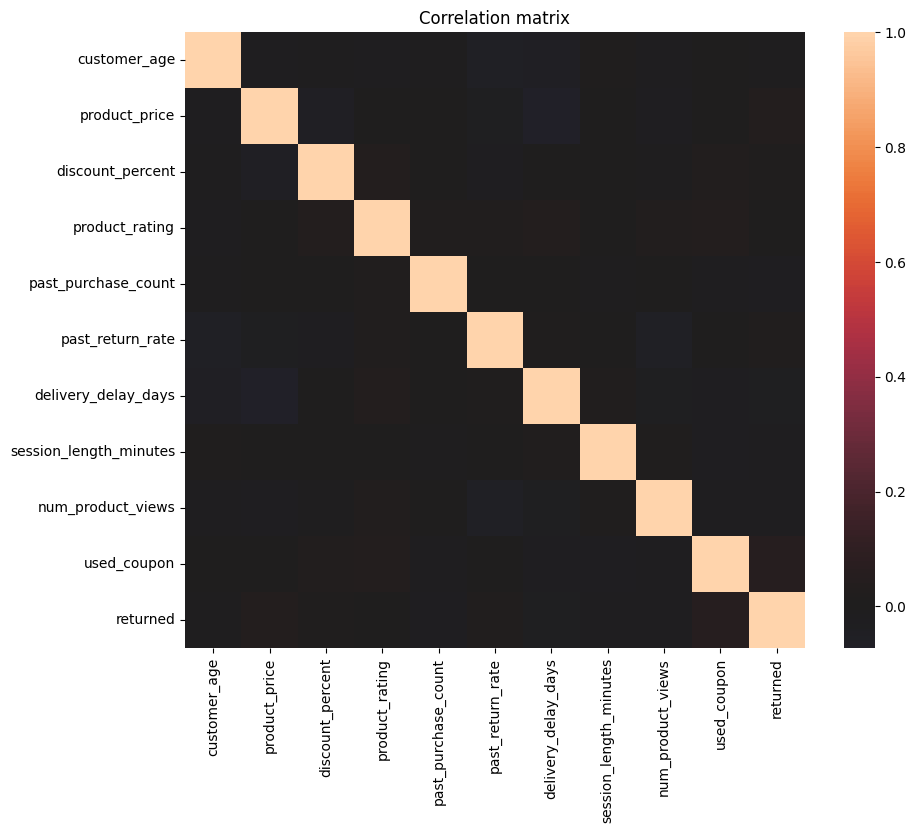

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_cols + ["returned"]].corr(), center=0)
plt.title("Correlation matrix")
plt.show()


Корреляционная матрица показывает, что между числовыми признаками нет сильных линейных зависимостей. Также отдельные числовые признаки слабо линейно коррелируют с целевой переменной `returned`. Это означает, что задача не решается простой линейной зависимостью, поэтому имеет смысл использовать нелинейные модели, например DecisionTree и RandomForest.